# Mixture of Experts: Why Input-Dependent Gating Matters

[source](https://pierrelucbacon.com/mlbook/ch6-probabilistic-models/#m-lange-dexperts)

A Mixture of Experts (MoE) models the conditional distribution as:

$$p(y \mid x) = \sum_{k=1}^{K} g_k(x)\, p(y \mid x, z{=}k)$$

where $g_k(x) = \frac{\exp(v_k^\top x)}{\sum_j \exp(v_j^\top x)}$ is a **softmax gating network** and each expert is a linear Gaussian: $p(y \mid x, z{=}k) = \mathcal{N}(y \mid w_k^\top x, \sigma_k^2)$.

The key insight is that **the gates depend on the input $x$**, allowing different experts to own different regions of input space. This demo compares:

- **Fixed gates** ($\pi_k$ constant) — a standard mixture of linear regressions
- **Input-dependent gates** ($g_k(x)$) — the full MoE model

Both are trained with EM on the same piecewise data to show how specialization only emerges with adaptive routing.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import Image
from pathlib import Path

## Synthetic Data

We create a piecewise-linear function with two distinct regimes — a rising slope for $x < 0$ and a falling slope for $x \geq 0$. A single linear model cannot fit this, but two experts can if they learn to **divide the input space**.

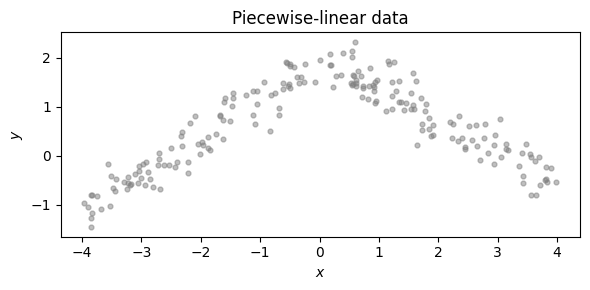

In [2]:
np.random.seed(0)
N = 200
x_raw = np.random.uniform(-4, 4, N)
noise = 0.3

# piecewise linear: rising then falling (a "tent" function)
y = np.where(x_raw < 0, 0.8 * x_raw + 2, -0.6 * x_raw + 2) + np.random.randn(N) * noise

# design matrix with bias
X = np.column_stack([np.ones(N), x_raw])  # (N, 2)
D = X.shape[1]
K = 2  # two experts

plt.figure(figsize=(6, 3))
plt.scatter(x_raw, y, s=12, alpha=0.5, c='gray')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title('Piecewise-linear data')
plt.tight_layout()
plt.show()

## EM Algorithm — Two Variants

Both models share the same E-step (compute responsibilities $r_{nk}$) and the same M-step for the expert parameters $w_k, \sigma_k^2$.

They differ **only in the gating update**:

| | Fixed gates | Input-dependent gates (MoE) |
|---|---|---|
| **Gate form** | $\pi_k$ (scalar) | $g_k(x) = \text{softmax}(v_k^\top x)$ |
| **M-step** | $\pi_k = \frac{1}{N}\sum_n r_{nk}$ | Gradient ascent: $v_k \leftarrow v_k + \eta \sum_n (r_{nk} - g_k(x_n))\, x_n$ |

In [3]:
def softmax(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(logits)
    return e / e.sum(axis=1, keepdims=True)


def e_step(X, y, gate_probs, w_list, sig2):
    """Compute responsibilities r_{nk}."""
    N, K = gate_probs.shape
    weighted = np.zeros((N, K))
    for k in range(K):
        mu_k = X @ w_list[k]
        weighted[:, k] = gate_probs[:, k] * norm.pdf(y, mu_k, np.sqrt(sig2[k]))
    r = weighted / (weighted.sum(axis=1, keepdims=True) + 1e-300)
    return r


def m_step_experts(X, y, r, K):
    """Weighted least-squares update for each expert."""
    w_list = []
    sig2 = np.zeros(K)
    for k in range(K):
        rk = r[:, k]
        Xr = np.sqrt(rk)[:, None] * X
        yr = np.sqrt(rk) * y
        wk = np.linalg.lstsq(Xr, yr, rcond=None)[0]
        w_list.append(wk)
        residual = y - X @ wk
        sig2[k] = np.sum(rk * residual**2) / (rk.sum() + 1e-10) + 1e-6
    return w_list, sig2


def run_fixed_gate_em(X, y, K, n_iter, rng):
    """Standard mixture of linear regressions (fixed pi_k)."""
    N, D = X.shape
    pi = np.ones(K) / K
    w_list = [np.linalg.lstsq(X, y, rcond=None)[0] + rng.randn(D) * 0.5 for _ in range(K)]
    sig2 = np.ones(K) * 1.0
    history = []

    for it in range(n_iter):
        gate_probs = np.tile(pi, (N, 1))  # constant across x
        r = e_step(X, y, gate_probs, w_list, sig2)
        w_list, sig2 = m_step_experts(X, y, r, K)
        pi = r.mean(axis=0)
        history.append((pi.copy(), [w.copy() for w in w_list], sig2.copy(), r.copy()))

    return history


def run_moe_em(X, y, K, n_iter, rng):
    """Mixture of Experts with input-dependent softmax gating."""
    N, D = X.shape
    V = rng.randn(K, D) * 0.1
    w_list = [np.linalg.lstsq(X, y, rcond=None)[0] + rng.randn(D) * 0.5 for _ in range(K)]
    sig2 = np.ones(K) * 1.0
    history = []

    for it in range(n_iter):
        g = softmax(X @ V.T)
        r = e_step(X, y, g, w_list, sig2)
        w_list, sig2 = m_step_experts(X, y, r, K)
        # gating gradient ascent
        for _ in range(30):
            g = softmax(X @ V.T)
            for k in range(K):
                V[k] += 0.05 * X.T @ (r[:, k] - g[:, k])
        history.append((V.copy(), [w.copy() for w in w_list], sig2.copy(), r.copy()))

    return history

In [4]:
# run both models with same initialization seed
n_iter = 30
rng_fixed = np.random.RandomState(7)
rng_moe = np.random.RandomState(7)

hist_fixed = run_fixed_gate_em(X, y, K, n_iter, rng_fixed)
hist_moe = run_moe_em(X, y, K, n_iter, rng_moe)

## Animation: Fixed Gates vs Input-Dependent Gates

Each frame is one EM iteration. Points are colored by responsibility $r_{n1}$ (orange = expert 1, blue = expert 2). The **top strip** shows $g_1(x)$ — the probability that expert 1 is selected.

- **Left (fixed gates):** $\pi_k$ is a horizontal line — both experts contribute equally everywhere, so neither can specialize.
- **Right (MoE):** $g_k(x)$ becomes a sigmoid that routes left-side points to one expert and right-side points to the other.

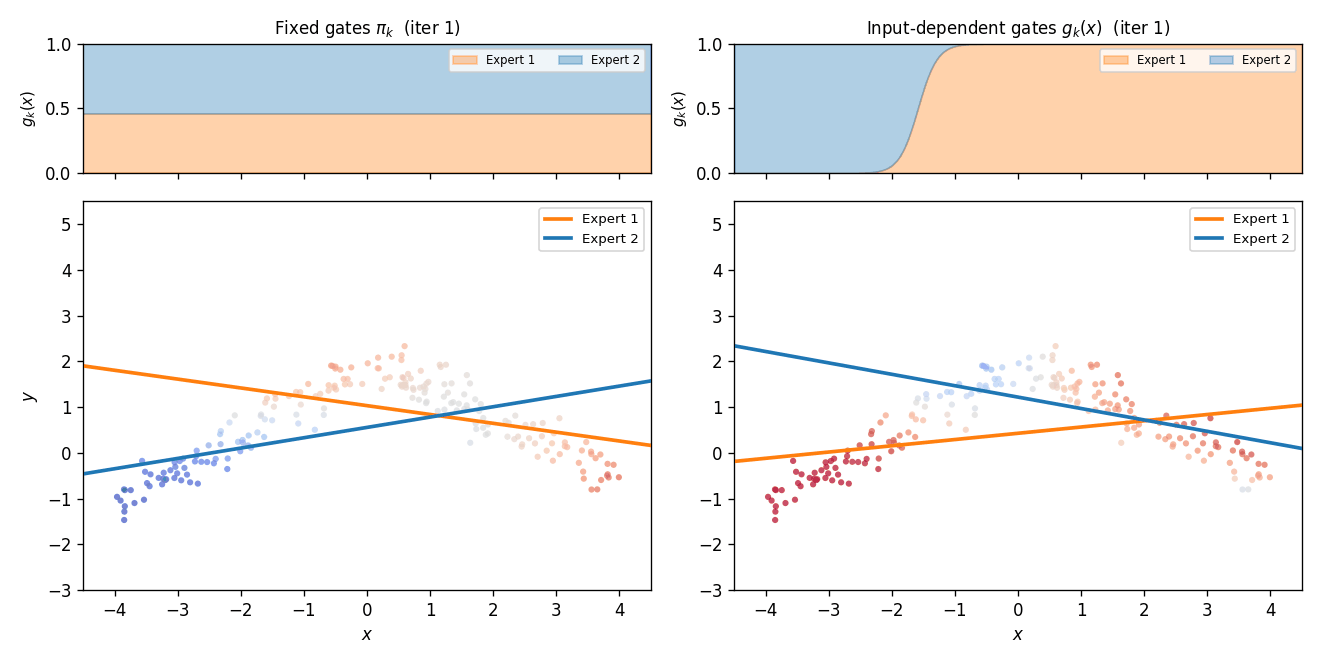

In [5]:
x_grid = np.linspace(-4.5, 4.5, 200)
X_grid = np.column_stack([np.ones_like(x_grid), x_grid])
expert_colors = ['tab:orange', 'tab:blue']

fig, axes = plt.subplots(2, 2, figsize=(11, 5.5),
                         gridspec_kw={'height_ratios': [1, 3]}, sharex='col')

def draw_frame(frame):
    for ax in axes.flat:
        ax.clear()

    for col, (hist, title) in enumerate([(hist_fixed, 'Fixed gates $\\pi_k$'),
                                          (hist_moe, 'Input-dependent gates $g_k(x)$')]):
        ax_gate = axes[0, col]
        ax_data = axes[1, col]
        params = hist[frame]
        gate_param, w_list, sig2, r = params

        # compute gate values on grid
        if col == 0:  # fixed
            g1_grid = np.full_like(x_grid, gate_param[0])
        else:  # moe
            V = gate_param
            g_grid = softmax(X_grid @ V.T)
            g1_grid = g_grid[:, 0]

        # gate plot
        ax_gate.fill_between(x_grid, 0, g1_grid, alpha=0.35, color=expert_colors[0], label='Expert 1')
        ax_gate.fill_between(x_grid, g1_grid, 1, alpha=0.35, color=expert_colors[1], label='Expert 2')
        ax_gate.set_ylim(0, 1)
        ax_gate.set_ylabel('$g_k(x)$', fontsize=9)
        ax_gate.set_title(f'{title}  (iter {frame+1})', fontsize=10)
        ax_gate.legend(fontsize=7, loc='upper right', ncol=2)

        # data + expert lines
        colors = plt.cm.coolwarm(r[:, 0])  # r_{n,0} maps to color
        ax_data.scatter(x_raw, y, c=colors, s=14, alpha=0.7, edgecolors='none')
        for k in range(K):
            y_pred = X_grid @ w_list[k]
            ax_data.plot(x_grid, y_pred, color=expert_colors[k], linewidth=2.2,
                         label=f'Expert {k+1}')
        ax_data.set_ylim(-3, 5.5)
        ax_data.set_xlim(-4.5, 4.5)
        ax_data.set_xlabel('$x$', fontsize=10)
        if col == 0:
            ax_data.set_ylabel('$y$', fontsize=10)
        ax_data.legend(fontsize=8, loc='upper right')

    fig.tight_layout()
    return []

anim = FuncAnimation(fig, draw_frame, frames=n_iter, interval=250, blit=True)

notebook_dir = Path("2026_02_23_moe.ipynb").resolve().parent
static_dir = notebook_dir / "static"
static_dir.mkdir(exist_ok=True)
anim.save(static_dir / 'moe_fixed_vs_adaptive.gif', writer='pillow', fps=4, dpi=120)
plt.close()

Image(filename=static_dir / 'moe_fixed_vs_adaptive.gif')

## Takeaway

With **fixed mixture weights** $\pi_k$, both experts are forced to share responsibility uniformly across all $x$ — they converge to similar compromise lines that average the two regimes, fitting neither well.

With **input-dependent gating** $g_k(x)$, the softmax gate learns a decision boundary (here near $x=0$) that cleanly routes each input region to the appropriate specialist. This is the core mechanism that makes Mixture of Experts powerful: **the routing network enables divide-and-conquer** over the input space.